Análisis de la frecuencia de especies y validación estadística de la proporción de Fraxinus pennsylvanica:

El siguiente código analiza la distribución de especies presentes en el dataset, con el objetivo de evaluar si Fraxinus pennsylvanica constituye más de un tercio del total de ejemplares censados. 
Primero se genera una tabla con las especies más frecuentes, excluyendo la categoría “Otra” para visualizar únicamente especies identificadas. Luego se calcula la proporción que representa *Fraxinus pennsylvanica* dentro del total de árboles, y finalmente se aplica un Test Z de una proporción para contrastar estadísticamente la hipótesis de que esta especie supera el umbral teórico del 33,33%. Además, se incluye un gráfico que muestra el porcentaje de representación de las 10 especies más comunes, destacando visualmente la dominancia de Fraxinus pennsylvanica.



Top 10 especies con mayor frecuencia:
nombre_cientifico
Fraxinus pennsylvanica    127973
Platanus x acerifolia      29960
Ficus benjamina            21379
Tilia x moltkei            14800
Melia azedarach            14036
Jacaranda mimosifolia      12790
Lagerstroemia indica       11356
Fraxinus americana          9621
Ligustrum lucidum           8624
Fraxinus excelsior          8201
Name: count, dtype: int64

Informacion de hipótesis: 
Total de árboles en el censo: 338991
Árboles de Fraxinus pennsylvanica: 127973
Proporción muestral p̂: 0.3775 (37.75 %)

Test Z de una proporción (H1: p > 1/3)
Z = 53.06
p-valor = 0.0000e+00


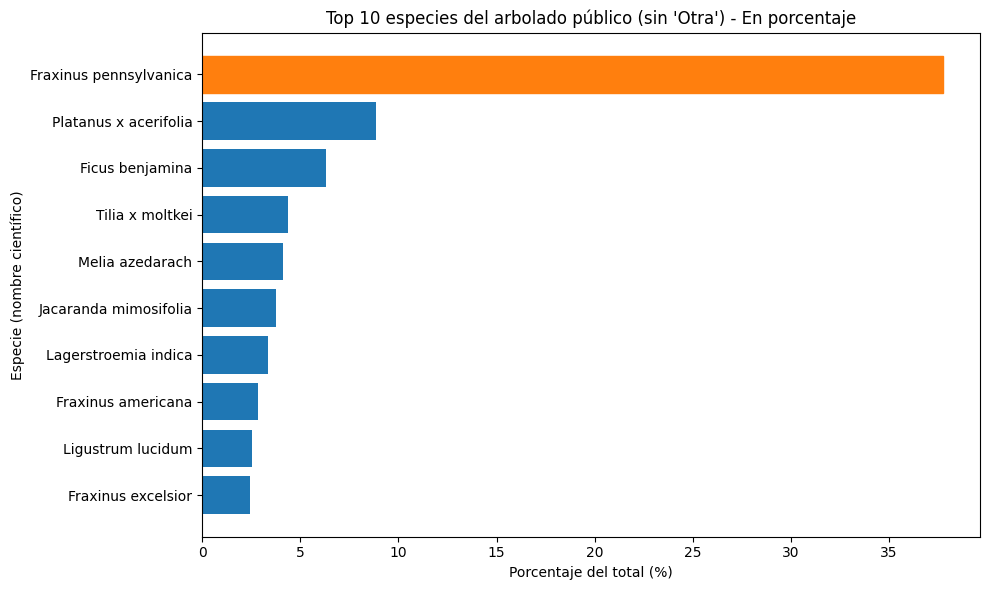

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import math

# Cargo los datos
df = pd.read_pickle("../data/datos_arbolado")

# Tabla de frecuencias por especie
freq_especies = df["nombre_cientifico"].value_counts()

# Mostrar el top 10 SIN incluir a "Otra"
freq_sin_otra = freq_especies.drop(labels=["Otra"], errors="ignore")

print("\nTop 10 especies con mayor frecuencia:")
print(freq_sin_otra.head(10))

# Proporción de Fraxinus pennsylvanica
especie_objetivo = "Fraxinus pennsylvanica"

n_total = len(df)
n_frax = (df["nombre_cientifico"] == especie_objetivo).sum()
p_hat = n_frax / n_total

print("\nInformacion de hipótesis: ")
print(f"Total de árboles en el censo: {n_total}")
print(f"Árboles de {especie_objetivo}: {n_frax}")
print(f"Proporción muestral p̂: {p_hat:.4f} ({p_hat*100:.2f} %)")

# Test Z de una proporción (H1: p > 1/3)
p0 = 1/3
z_stat, p_value = proportions_ztest(
    count=n_frax,
    nobs=n_total,
    value=p0,
    alternative="larger"
)

print("\nTest Z de una proporción (H1: p > 1/3)")
print(f"Z = {z_stat:.2f}")
print(f"p-valor = {p_value:.4e}")

#Grafico porcentaje de frecuencia de cada especie

top_n = 10
top_especies = freq_sin_otra.head(top_n)

# Convierto cantidad de muestras por especie a porcentajes
porcentajes = (top_especies / n_total * 100).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(porcentajes.index, porcentajes.values)

# Resaltar Fraxinus pennsylvanica, ya que es la especie que estamos analizando
for bar, nombre in zip(bars, porcentajes.index):
    if nombre == especie_objetivo:
        bar.set_color("tab:orange")

plt.xlabel("Porcentaje del total (%)")
plt.ylabel("Especie (nombre científico)")
plt.title(f"Top {top_n} especies del arbolado público (sin 'Otra') - En porcentaje")
plt.tight_layout()
plt.show()


Visualización del Test Z para la hipótesis Fraxinus > 1/3

El siguiente código genera una gráfica que ayuda a interpretar visualmente el resultado del test Z utilizado en la hipotesis
La figura muestra:
- La distribución normal estándar bajo la hipótesis nula.  
- La región de no rechazo (valores de Z menores al crítico).  
- La región de rechazo (cola derecha, donde p < 0.05).  
- El valor crítico del test Z para un nivel de significancia de α = 0.05.  
- El valor Z observado en nuestro análisis, para verificar si cae en la zona crítica.

Esta visualización permite entender de manera gráfica por qué la hipótesis nula se rechaza y cuán lejos se encuentra el valor observado respecto del umbral teórico.


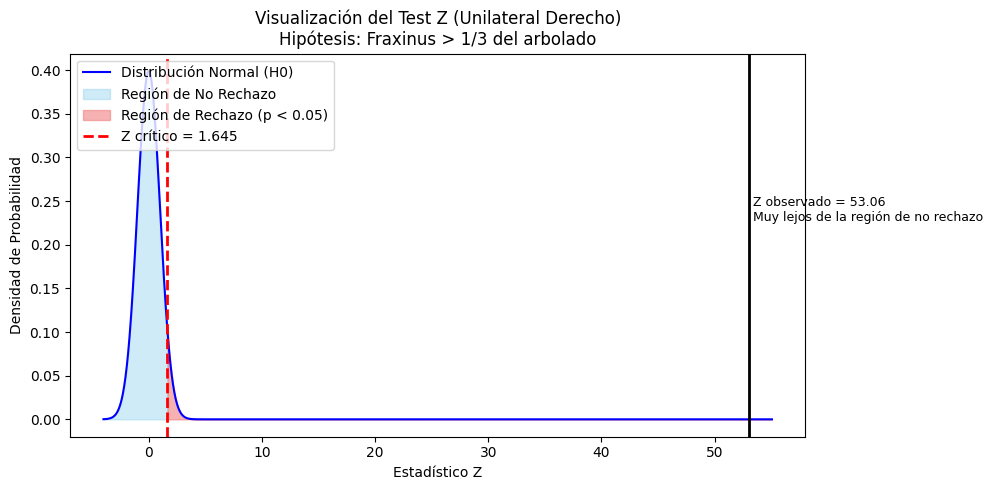

In [37]:
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
from scipy.stats import norm

# Grafico del Test Z (unilateral derecho)
# Utilizo un nivel de significacia alfa = 0.05 en un test unilateral derecho
z_crit = round(norm.ppf(0.95), 3)

# Genero un rango amplio de valores de Z para graficar
x_max = max(6, z_stat + 2)  # si el Z observado es muy grande, extiende el eje
x = np.linspace(-4, x_max, 2000)
y = norm.pdf(x)

plt.figure(figsize=(10,5))

# Curva de la distribución normal estándar bajo H0
plt.plot(x, y, color="blue", label="Distribución Normal (H0)")

# Región de NO rechazo del test (Z < Z crítico)
mask_no_rech = x <= z_crit
plt.fill_between(x[mask_no_rech], 0, y[mask_no_rech],
                 color="skyblue", alpha=0.4, label="Región de No Rechazo")

# Región de rechazo del test (Z > Z crítico)
mask_rech = x >= z_crit
plt.fill_between(x[mask_rech], 0, y[mask_rech],
                 color="lightcoral", alpha=0.6, label="Región de Rechazo (p < 0.05)")

# Línea vertical indicando el valor crítico del test Z
plt.axvline(z_crit, color="red", linestyle="--", linewidth=2,
            label=f"Z crítico = {z_crit}")

# Línea vertical indicando el Z observado
plt.axvline(z_stat, color="black", linewidth=2)

# Mensaje según el valor de Z observado
if z_stat < z_crit:
    mensaje = "No supera el valor crítico"
elif z_stat < z_crit + 2:
    mensaje = "Supera ligeramente el valor crítico"
elif z_stat < z_crit + 10:
    mensaje = "Claramente esta en la región de rechazo"
else:
    mensaje = "Muy lejos de la región de no rechazo"

# Muestro el texto junto al Z observado
plt.text(z_stat + 0.3, max(y)*0.6,
         f"Z observado = {z_stat:.2f}\n{mensaje}",
         fontsize=9, verticalalignment="center")

# Títulos y etiquetas del gráfico
plt.title("Visualización del Test Z (Unilateral Derecho)\nHipótesis: Fraxinus > 1/3 del arbolado")
plt.xlabel("Estadístico Z")
plt.ylabel("Densidad de Probabilidad")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


La visualización muestra que el valor crítico para un test unilateral derecho con α = 0.05 es Z = 1.645, mientras que el valor observado en nuestro análisis, Z ≈ 53, se ubica extremadamente lejos hacia la derecha, muy por fuera de la región de no rechazo. Esta distancia tan amplia respecto del umbral teórico evidencia que la proporción de Fraxinus pennsylvanica en el arbolado urbano es significativamente mayor que un tercio. En consecuencia, la hipótesis nula se rechaza de manera contundente y se confirma la dominancia de esta especie en el arbolado público de la ciudad.